In [1]:
!pip install rdkit

!pip install torch-geometric
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 51.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.5 MB/s eta 0:00:00


In [ ]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 45.7 MB/s eta 0:00:00


In [ ]:
# ----------------------- 1. İTHALATLAR VE SABİTLER -----------------------

import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score, roc_curve, auc,
    accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.model_selection import StratifiedKFold
from scipy.stats import ttest_rel, wilcoxon

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import WeightedRandomSampler
from torch_geometric.loader import DataLoader

from torch_geometric.data import Data, Dataset
from torch_geometric.nn import GINConv, global_mean_pool
from torch_geometric.utils import add_self_loops

from rdkit import Chem
from rdkit.Chem import Descriptors

# Sabitler
SEED           = 42
BATCH_SIZE     = 128
LR_BASE        = 1e-4
WEIGHT_DECAY   = 1e-3
EPOCHS         = 60
PATIENCE       = 8
HIDDEN_DIM     = 128
N_LAYERS       = 4
DROPOUT_RATE   = 0.2
DEVICE         = torch.device("cuda" if torch.cuda.is_available() else "cpu")
FCL_ALPHA      = 0.25
FCL_GAMMA      = 2.0

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
warnings.filterwarnings("ignore", category=UserWarning)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

In [ ]:
# ----------------------- 2. FEATURIZER VE SMILES→Data -----------------------

class Featurizer:
    def __init__(self, allow_map):
        self.dim, self.map = 0, {}
        for key, vals in allow_map.items():
            sorted_vals = sorted(list(vals))
            self.map[key] = {v: i + self.dim for i, v in enumerate(sorted_vals)}
            self.dim += len(sorted_vals)

    def _encode(self, obj):
        vec = np.zeros(self.dim, dtype=np.float32)
        for method_name, mapping in self.map.items():
            val = getattr(self, method_name)(obj)
            if val in mapping:
                vec[mapping[val]] = 1.0
        return vec

class AtomFeat(Featurizer):
    def n_number(self, atom):            return atom.GetAtomicNum()
    def n_valence(self, atom):           return atom.GetTotalValence()
    def n_hydrogens(self, atom):         return atom.GetTotalNumHs()
    def hybridization(self, atom):       return atom.GetHybridization().name.lower()
    def n_degree(self, atom):            return atom.GetDegree()
    def n_radical_electrons(self, atom): return atom.GetNumRadicalElectrons()
    def is_in_ring(self, atom):          return atom.IsInRing()
    def encode(self, atom):              return self._encode(atom)

class BondFeat(Featurizer):
    def __init__(self, allow_map):
        super().__init__(allow_map)
        self.dim += 1

    def bond_type(self, bond):      return bond.GetBondType().name.lower()
    def conjugated(self, bond):     return bond.GetIsConjugated()

    def encode(self, bond):
        if bond is None:
            vec = np.zeros(self.dim, dtype=np.float32)
            vec[-1] = 1.0
            return vec
        return self._encode(bond)

# Atom ve bond öznitelik haritaları
ATOM_FTR = AtomFeat({
    "n_number":           {1, 5, 6, 8, 9, 11, 15, 16, 17, 20, 35, 53},
    "n_valence":          {0, 1, 2, 3, 4, 5, 6},
    "n_hydrogens":        {0, 1, 2, 3, 4},
    "hybridization":      {"s", "sp", "sp2", "sp3"},
    "n_degree":           {0, 1, 2, 3, 4, 5, 6},
    "n_radical_electrons":{0, 1, 2, 3, 4},
    "is_in_ring":         {True, False}
})
BOND_FTR = BondFeat({
    "bond_type":  {"single", "double", "triple", "aromatic"},
    "conjugated": {True, False}
})

def mol_from_smiles(smiles, randomize=False):
    """
    RDKit ile SMILES → Mol dönüştürür. Eğer randomize=True ise,
    MolToSmiles(doRandom=True) yöntemiyle rastgele bir düzenleme yapar.
    """
    if randomize:
        base = Chem.MolFromSmiles(smiles)
        smiles = Chem.MolToSmiles(base, doRandom=True)
    mol = Chem.MolFromSmiles(smiles, sanitize=False)
    flag = Chem.SanitizeMol(mol, catchErrors=True)
    if flag != Chem.SanitizeFlags.SANITIZE_NONE:
        Chem.SanitizeMol(mol, Chem.SanitizeFlags.SANITIZE_ALL ^ flag)
    Chem.AssignStereochemistry(mol, cleanIt=True, force=True)
    return mol

def pyg_from_mol(mol, y=None):
    """
    RDKit Mol → PyG Data objesine çevirir:
    - Atomlar için ATOM_FTR.encode ile özellik vektörü
    - Bağlar için BOND_FTR.encode
    """
    x = torch.from_numpy(
        np.stack([ATOM_FTR.encode(atom) for atom in mol.GetAtoms()])
    ).float()

    edge_index_list, edge_attr_list = [], []
    num_atoms = mol.GetNumAtoms()

    # Self-loop ekle (bond=None)
    for i in range(num_atoms):
        edge_index_list.append([i, i])
        edge_attr_list.append(BOND_FTR.encode(None))

    # Gerçek bağlar
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        f = BOND_FTR.encode(bond)
        edge_index_list += [[i, j], [j, i]]
        edge_attr_list += [f, f]

    edge_index = torch.tensor(edge_index_list, dtype=torch.long).t().contiguous()
    edge_attr = torch.tensor(np.stack(edge_attr_list), dtype=torch.float)

    data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr)
    if y is not None:
        data.y = torch.tensor([y], dtype=torch.float)
    return data

def compute_descriptors(smiles):
    """
    RDKit kullanarak molekül düzeyinde 6 boyutlu descriptor çıkarır:
    MolLogP, MolWt, TPSA, NumHAcceptors, NumHDonors, NumRotatableBonds
    """
    m = Chem.MolFromSmiles(smiles)
    descs = [
        Descriptors.MolLogP(m),
        Descriptors.MolWt(m),
        Descriptors.TPSA(m),
        Descriptors.NumHAcceptors(m),
        Descriptors.NumHDonors(m),
        Descriptors.NumRotatableBonds(m)
    ]
    return np.array(descs, dtype=np.float32)

def add_virtual_node(data):
    """
    Her grafın sonuna bir "virtual node" ekler. Bu düğüm
    yalnızca global descriptor bilgisini aktarmak için kullanılır.
    """
    num_nodes = data.x.size(0)
    feat_dim = data.x.size(1)

    # Sanal düğüm feature: sıfır vektör (global_desc model içinde kullanılıyor)
    vn_feat = torch.zeros((1, feat_dim), device=data.x.device)
    data.x = torch.cat([data.x, vn_feat], dim=0)

    # Batch tensor'una ekle
    data.batch = torch.cat([data.batch, data.batch.new_full((1,), data.batch[0])], dim=0)

    # Sanal düğüm index'i
    vs = num_nodes
    existing = torch.arange(0, num_nodes, device=data.x.device)

    # Sanal → her atom (kolektif bağlantı)
    e1 = torch.stack([torch.full((num_nodes,), vs, device=data.x.device), existing], dim=0)
    # Her atom → sanal
    e2 = torch.stack([existing, torch.full((num_nodes,), vs, device=data.x.device)], dim=0)

    data.edge_index = torch.cat([data.edge_index, e1, e2], dim=1)

    # Kenar özniteliği ekle (bond_dim = mevcut bond öznitelik sayısı)
    bond_dim = data.edge_attr.size(1)
    new_edge_attr = torch.zeros((num_nodes * 2, bond_dim), device=data.edge_attr.device)
    data.edge_attr = torch.cat([data.edge_attr, new_edge_attr], dim=0)

    return data



In [ ]:
# ----------------------- 3. DATASET -----------------------

class HIVDatasetVN(Dataset):
    """
    Her satır için:
    - SMILES → Mol → pyg_from_mol ile PyG Data objesi
    - data.global_desc: [1×6] tensor olarak descriptor bilgisi
    - Eğer virtual_node=True ise add_virtual_node(data) çağrılır
    """
    def __init__(self, df, augment=False, virtual_node=False):
        super().__init__()
        self.df = df.reset_index(drop=True)
        self.aug = augment
        self.virtual_node = virtual_node

    def len(self):
        return len(self.df)

    def get(self, idx):
        row = self.df.iloc[idx]
        smiles = row.smiles
        mol = mol_from_smiles(smiles, self.aug)
        data = pyg_from_mol(mol, row.HIV_active)

        # Descriptor'ı 1×6 tensor olarak ekle
        desc = compute_descriptors(smiles)                                # shape (6,)
        data.global_desc = torch.tensor(desc, dtype=torch.float).unsqueeze(0)  # shape (1×6)

        # Batch bilgisi: her atom için 0 (tek graf)
        data.batch = torch.tensor([0] * data.x.size(0), dtype=torch.long)

        if self.virtual_node:
            data = add_virtual_node(data)

        return data



In [ ]:
# ----------------------- 4. FOCAL LOSS -----------------------

from torchvision.ops import sigmoid_focal_loss

def focal_loss(inputs, targets, alpha=FCL_ALPHA, gamma=FCL_GAMMA):
    """
    Sigmoid Focal Loss uygular.
    - inputs: logits (batch_size)
    - targets: 0/1 etiketleri (batch_size)
    """
    return sigmoid_focal_loss(inputs, targets, alpha=alpha, gamma=gamma, reduction='mean')

class GIN_MPNN(nn.Module):
    def __init__(self, in_dim, hidden_dim=HIDDEN_DIM, n_layers=N_LAYERS,
                 dropout=DROPOUT_RATE, desc_dim=0):
        super().__init__()
        self.convs = nn.ModuleList()
        self.bns   = nn.ModuleList()
        self.dropout = nn.Dropout(dropout)

        # İlk GINConv katmanı (in_dim → hidden_dim)
        mlp1 = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )
        self.convs.append(GINConv(mlp1))
        self.bns.append(nn.BatchNorm1d(hidden_dim))

        # Diğer GIN katmanları (hidden_dim → hidden_dim)
        for _ in range(n_layers - 1):
            mlpi = nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim)
            )
            self.convs.append(GINConv(mlpi))
            self.bns.append(nn.BatchNorm1d(hidden_dim))

        self.read = global_mean_pool

        # Descriptor projeksiyon bloğu (desc_dim → hidden_dim//4)
        if desc_dim > 0:
            self.desc_proj = nn.Sequential(
                nn.Linear(desc_dim, hidden_dim // 2),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(hidden_dim // 2, hidden_dim // 4),
                nn.ReLU()
            )
            total_emb_dim = hidden_dim + hidden_dim // 4
        else:
            self.desc_proj = None
            total_emb_dim = hidden_dim

        # Son MLP: total_emb_dim → total_emb_dim//2 → total_emb_dim//4 → 1
        self.mlp = nn.Sequential(
            nn.Linear(total_emb_dim, total_emb_dim // 2),
            nn.BatchNorm1d(total_emb_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(total_emb_dim // 2, total_emb_dim // 4),
            nn.BatchNorm1d(total_emb_dim // 4),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(total_emb_dim // 4, 1)
        )

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        h = x
        for conv, bn in zip(self.convs, self.bns):
            h = conv(h, edge_index)
            h = bn(h)
            h = F.relu(h)
            h = self.dropout(h)

        # Global mean pooling → graph seviyesi vektör (batch_size×hidden_dim)
        g = self.read(h, batch)

        # Descriptor projeksiyonu varsa, concat et
        if self.desc_proj is not None:
            # data.global_desc: shape (batch_size × desc_dim)
            d = self.desc_proj(data.global_desc.to(DEVICE))
            g = torch.cat([g, d], dim=1)

        out = self.mlp(g).view(-1)
        return out



In [ ]:
# ----------------------- 6. EĞİTİM VE DOĞRULAMA FONKSİYONLARI -----------------------

def run_epoch_onecycle(loader, model, crit, optimizer, scheduler):
    """
    Her batch sonunda scheduler.step() çağrılan OneCycleLR protokolü ile bir epoch eğitimi.
    """
    model.train()
    total_loss, true_list, pred_list = 0.0, [], []

    for batch in loader:
        batch = batch.to(DEVICE)
        logits = model(batch)
        loss = crit(logits, batch.y)

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 0.5)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item() * batch.num_graphs
        true_list.append(batch.y.detach().cpu().numpy())
        pred_list.append(torch.sigmoid(logits.detach()).cpu().numpy())

    true_all = np.concatenate(true_list)
    pred_all = np.concatenate(pred_list)
    auc_score = roc_auc_score(true_all, pred_all)
    return total_loss / len(loader.dataset), auc_score

def run_validation(loader, model, crit, threshold=0.5):
    """
    Validation veya test aşaması:
    loss + Accuracy + Precision + Recall + F1 + ROC-AUC döndürür.
    """
    model.eval()
    total_loss, true_list, pred_list = 0.0, [], []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(DEVICE)
            logits = model(batch)
            loss = crit(logits, batch.y)

            total_loss += loss.item() * batch.num_graphs
            true_list.append(batch.y.detach().cpu().numpy())
            pred_list.append(torch.sigmoid(logits).detach().cpu().numpy())

    true_all = np.concatenate(true_list)
    pred_all = np.concatenate(pred_list)
    pred_bin = (pred_all >= threshold).astype(int)

    metrics = {
        "loss": total_loss / len(loader.dataset),
        "accuracy": accuracy_score(true_all, pred_bin),
        "precision": precision_score(true_all, pred_bin, zero_division=0),
        "recall": recall_score(true_all, pred_bin, zero_division=0),
        "f1": f1_score(true_all, pred_bin, zero_division=0),
        "roc_auc": roc_auc_score(true_all, pred_all)
    }

    return metrics, true_all, pred_all

def train_onecycle(train_loader, val_loader, sample_data, desc_dim):
    """
    Modeli OneCycleLR scheduler ile eğitir, her epoch sonunda validation yapar.
    """
    model = GIN_MPNN(
        in_dim=sample_data.x.size(1),
        hidden_dim=HIDDEN_DIM,
        n_layers=N_LAYERS,
        dropout=DROPOUT_RATE,
        desc_dim=desc_dim
    ).to(DEVICE)

    crit = focal_loss
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR_BASE, weight_decay=WEIGHT_DECAY)

    total_steps = EPOCHS * len(train_loader)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=LR_BASE,
        total_steps=total_steps,
        pct_start=0.1,
        anneal_strategy='cos',
        final_div_factor=10
    )

    best_val_auc = 0.0
    wait = 0
    history = {'tr_auc': [], 'va_auc': [], 'tr_ls': [], 'va_ls': []}

    for epoch in range(1, EPOCHS + 1):
        tr_loss, tr_auc = run_epoch_onecycle(train_loader, model, crit, optimizer, scheduler)
        val_metrics, _, _ = run_validation(val_loader, model, crit)

        va_loss = val_metrics["loss"]
        va_auc = val_metrics["roc_auc"]

        history['tr_ls'].append(tr_loss)
        history['va_ls'].append(va_loss)
        history['tr_auc'].append(tr_auc)
        history['va_auc'].append(va_auc)

        print(
            f"Epoch {epoch:02d}  "
            f"Loss: {tr_loss:.4f}/{va_loss:.4f}  "
            f"AUC: {tr_auc:.3f}/{va_auc:.3f}  "
            f"Gap: {tr_auc - va_auc:.3f}"
        )

        if va_auc > best_val_auc + 1e-4:
            best_val_auc = va_auc
            wait = 0
            torch.save(model.state_dict(), "best_model_onecycle.pt")
        else:
            wait += 1
            if wait >= PATIENCE:
                print("Early stopping tetiklendi.")
                break

    model.load_state_dict(torch.load("best_model_onecycle.pt"))
    return model, history, best_val_auc

In [ ]:
# ----------------------- 7. CROSS-VALIDATION VE EĞİTİM -----------------------

def cross_validate_training(df, k_folds=5):
    """
    Stratified K-Fold cross-validation:
    - Her fold için train/val/test ayrımı yapar.
    - Fold bazlı Accuracy, Precision, Recall, F1, ROC-AUC üretir.
    - Mean ± std ve variance hesaplar.
    """
    skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=SEED)

    all_histories = []
    fold_results = []

    for fold, (train_idx, temp_idx) in enumerate(
            skf.split(df.smiles, df.HIV_active), start=1):

        print(f"\n{'='*25} FOLD {fold} {'='*25}")
        set_seed(SEED + fold)

        df_train = df.iloc[train_idx].reset_index(drop=True)
        df_temp  = df.iloc[temp_idx].reset_index(drop=True)

        df_temp = df_temp.sample(frac=1.0, random_state=SEED + fold).reset_index(drop=True)
        half = len(df_temp) // 2
        df_val = df_temp[:half].reset_index(drop=True)
        df_test = df_temp[half:].reset_index(drop=True)

        print(f"Train: {len(df_train)}, Val: {len(df_val)}, Test: {len(df_test)}")

        train_ds = HIVDatasetVN(df_train, augment=True, virtual_node=True)
        val_ds   = HIVDatasetVN(df_val, augment=False, virtual_node=True)
        test_ds  = HIVDatasetVN(df_test, augment=False, virtual_node=True)

        labels_train = df_train.HIV_active.values
        class_counts = np.array([len(np.where(labels_train == t)[0]) for t in np.unique(labels_train)])
        weights = 1.0 / class_counts
        samples_weight = np.array([weights[int(t)] for t in labels_train])
        samples_weight = torch.from_numpy(samples_weight).double()
        sampler = WeightedRandomSampler(samples_weight, num_samples=len(samples_weight), replacement=True)

        train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2)
        val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
        test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

        sample_data = train_ds.get(0)
        model, history, best_val_auc = train_onecycle(
            train_loader, val_loader, sample_data, desc_dim=6
        )

        all_histories.append(history)

        crit = focal_loss
        val_metrics, val_true, val_pred = run_validation(val_loader, model, crit)
        test_metrics, test_true, test_pred = run_validation(test_loader, model, crit)

        fold_result = {
            "fold": fold,
            "val_accuracy": val_metrics["accuracy"],
            "val_precision": val_metrics["precision"],
            "val_recall": val_metrics["recall"],
            "val_f1": val_metrics["f1"],
            "val_roc_auc": val_metrics["roc_auc"],
            "test_accuracy": test_metrics["accuracy"],
            "test_precision": test_metrics["precision"],
            "test_recall": test_metrics["recall"],
            "test_f1": test_metrics["f1"],
            "test_roc_auc": test_metrics["roc_auc"]
        }
        fold_results.append(fold_result)

        print(f"\nFold {fold} Validation Results:")
        print({k: round(v, 4) for k, v in fold_result.items() if k.startswith('val_')})

        print(f"Fold {fold} Test Results:")
        print({k: round(v, 4) for k, v in fold_result.items() if k.startswith('test_')})

    results_df = pd.DataFrame(fold_results)

    summary = {}
    test_metric_cols = ["test_accuracy", "test_precision", "test_recall", "test_f1", "test_roc_auc"]

    for col in test_metric_cols:
        summary[col] = {
            "mean": results_df[col].mean(),
            "std": results_df[col].std(ddof=1),
            "var": results_df[col].var(ddof=1)
        }

    print("\n" + "="*60)
    print("5-FOLD CROSS-VALIDATION TEST SONUÇLARI")
    print("="*60)
    for col in test_metric_cols:
        print(
            f"{col}: "
            f"{summary[col]['mean']:.4f} ± {summary[col]['std']:.4f} "
            f"(var={summary[col]['var']:.6f})"
        )

    return all_histories, results_df, summary


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def pad_to_length(lst, target_len):
    if len(lst) >= target_len:
        return lst[:target_len]
    return lst + [lst[-1]] * (target_len - len(lst))

def plot_avg_training_history(histories, max_epoch=35):
    """
    histories: all_histories listesi. Her eleman bir fold'a ait history sözlüğüdür.
    max_epoch: her fold’un kullanılacak epoch sayısı
    """
    tr_auc_matrix = []
    va_auc_matrix = []
    tr_ls_matrix  = []
    va_ls_matrix  = []

    for h in histories:
        tr_auc_matrix.append(pad_to_length(h['tr_auc'], max_epoch))
        va_auc_matrix.append(pad_to_length(h['va_auc'], max_epoch))
        tr_ls_matrix.append(pad_to_length(h['tr_ls'], max_epoch))
        va_ls_matrix.append(pad_to_length(h['va_ls'], max_epoch))

    # Ortalama hesaplamaları
    avg_tr_auc = np.mean(tr_auc_matrix, axis=0)
    avg_va_auc = np.mean(va_auc_matrix, axis=0)
    avg_tr_ls  = np.mean(tr_ls_matrix, axis=0)
    avg_va_ls  = np.mean(va_ls_matrix, axis=0)

    epochs = range(1, max_epoch + 1)

    # AUC Grafiği
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, avg_tr_auc, label='Avg Train AUC', alpha=0.8, marker='o')
    plt.plot(epochs, avg_va_auc, label='Avg Val AUC', alpha=0.8, marker='s')
    plt.xlabel('Epoch')
    plt.ylabel('AUC')
    plt.title(f'Train vs. Validation AUC with Earlystopping')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    # Loss Grafiği
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, avg_tr_ls, label='Avg Train Loss', alpha=0.8, marker='o')
    plt.plot(epochs, avg_va_ls, label='Avg Val Loss', alpha=0.8, marker='s')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'Train vs. Validation Loss with Earlystopping')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()



In [ ]:
# ----------------------- 9. ANA BLOK -----------------------
if __name__ == "__main__":
    df_all = pd.read_csv("https://raw.githubusercontent.com/McahitKutsal/hivcsv/main/HIV7.csv")
    df_all = df_all.sample(frac=1.0, random_state=SEED).reset_index(drop=True)

    all_histories, results_df, summary = cross_validate_training(df_all, k_folds=5)

    print("\nFold bazlı sonuçlar:")
    display(results_df)

    results_df.to_csv("GDL_fold_results.csv", index=False)

    summary_rows = []
    for metric_name, vals in summary.items():
        summary_rows.append({
            "Metric": metric_name.replace("test_", "").upper(),
            "Mean": vals["mean"],
            "Std": vals["std"],
            "Variance": vals["var"],
            "Formatted": f"{vals['mean']:.4f} ± {vals['std']:.4f}"
        })

    summary_df = pd.DataFrame(summary_rows)
    print("\nÖzet tablo:")
    display(summary_df)

    summary_df.to_csv("GDL_summary_results.csv", index=False)


========================= FOLD 1 =========================
Train: 2308, Val: 288, Test: 289
Epoch 01  Loss: 0.0733/0.0688  AUC: 0.759/0.921  Gap: -0.162
Epoch 02  Loss: 0.0735/0.0647  AUC: 0.773/0.923  Gap: -0.150
Epoch 03  Loss: 0.0679/0.0607  AUC: 0.809/0.935  Gap: -0.126
Epoch 04  Loss: 0.0649/0.0583  AUC: 0.814/0.940  Gap: -0.125
Epoch 05  Loss: 0.0590/0.0538  AUC: 0.852/0.941  Gap: -0.088
Epoch 06  Loss: 0.0558/0.0504  AUC: 0.857/0.939  Gap: -0.082
Epoch 07  Loss: 0.0515/0.0483  AUC: 0.884/0.939  Gap: -0.055
Epoch 08  Loss: 0.0496/0.0467  AUC: 0.880/0.935  Gap: -0.055
Epoch 09  Loss: 0.0464/0.0438  AUC: 0.896/0.938  Gap: -0.042
Epoch 10  Loss: 0.0481/0.0429  AUC: 0.878/0.940  Gap: -0.062
Epoch 11  Loss: 0.0443/0.0433  AUC: 0.899/0.942  Gap: -0.042
Epoch 12  Loss: 0.0435/0.0410  AUC: 0.902/0.945  Gap: -0.043
Epoch 13  Loss: 0.0437/0.0387  AUC: 0.899/0.948  Gap: -0.049
Epoch 14  Loss: 0.0418/0.0403  AUC: 0.914/0.948  Gap: -0.035
Epoch 15  Loss: 0.0394/0.0375  AUC: 0.922/0.951  Gap:

,fold,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
0,1,0.864583,1.000,0.746753,0.855019,0.966660,0.868512,1.00000,0.728571,0.842975,0.938878
1,2,0.822917,1.000,0.633094,0.775330,0.927720,0.823529,1.00000,0.670968,0.803089,0.944391
2,3,0.875000,1.000,0.772152,0.871429,0.942648,0.882353,1.00000,0.751825,0.858333,0.973396
3,4,0.875000,0.975,0.780000,0.866667,0.952657,0.889273,0.97479,0.800000,0.878788,0.954119
4,5,0.885417,1.000,0.765957,0.867470,0.943841,0.899654,1.00000,0.811688,0.896057,0.972102



Özet tablo:


,Metric,Mean,Std,Variance,Formatted
0,ACCURACY,0.872664,0.029705,0.000882,0.8727 ± 0.0297
1,PRECISION,0.994958,0.011274,0.000127,0.9950 ± 0.0113
2,RECALL,0.752610,0.056965,0.003245,0.7526 ± 0.0570
3,F1,0.855849,0.035702,0.001275,0.8558 ± 0.0357
4,ROC_AUC,0.956577,0.015746,0.000248,0.9566 ± 0.0157


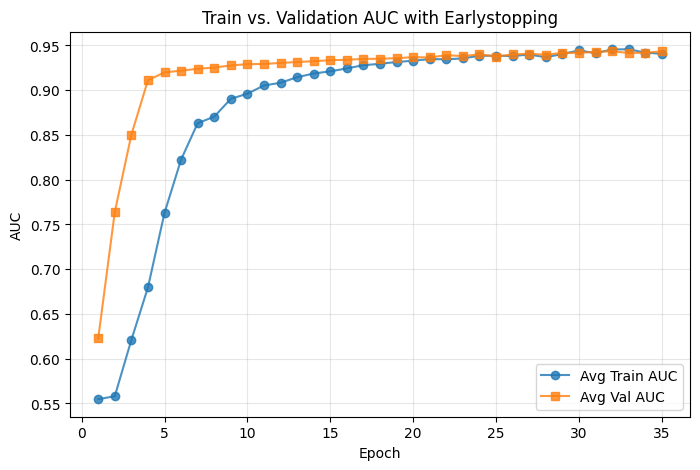

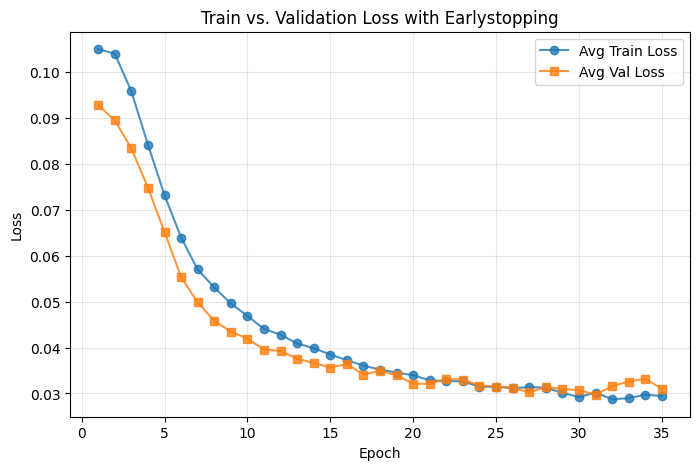

In [ ]:
plot_avg_training_history(all_histories, max_epoch=35)

## GDL docking preparation block

Bu blok Colab için hazırlanmıştır ve prediction sonrası post-processing amacıyla eklenmiştir.

Eklenen akış:
- RDKit kurulum hücresi
- mevcut tahminlerden/top skorlarından 13 sütunlu tablo üretimi
- top 10 aday
- final 2 aday
- renkli 2D çizim
- `.smi` docking dosyası

In [ ]:
# Colab RDKit install
import sys, subprocess, pkgutil

if pkgutil.find_loader("rdkit") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "rdkit-pypi"])

from rdkit import Chem
from rdkit.Chem import Descriptors, Draw
from rdkit.Chem import Lipinski as RdLipinski, Crippen, QED

print("RDKit OK")

RDKit OK


/tmp/ipykernel_7830/359356715.py:4: DeprecationWarning: 'pkgutil.find_loader' is deprecated and slated for removal in Python 3.14; use importlib.util.find_spec() instead
  if pkgutil.find_loader("rdkit") is None:


Using AUC column: test_roc_auc
Using best fold: 3
Train: 2308, Val: 288, Test: 289
Epoch 01  Loss: 0.1188/0.1039  AUC: 0.443/0.482  Gap: -0.039
Epoch 02  Loss: 0.1180/0.0969  AUC: 0.441/0.732  Gap: -0.291
Epoch 03  Loss: 0.1086/0.0931  AUC: 0.502/0.875  Gap: -0.373
Epoch 04  Loss: 0.0929/0.0768  AUC: 0.617/0.901  Gap: -0.284
Epoch 05  Loss: 0.0794/0.0696  AUC: 0.725/0.903  Gap: -0.177
Epoch 06  Loss: 0.0699/0.0566  AUC: 0.810/0.905  Gap: -0.095
Epoch 07  Loss: 0.0617/0.0491  AUC: 0.841/0.906  Gap: -0.065
Epoch 08  Loss: 0.0547/0.0431  AUC: 0.871/0.909  Gap: -0.038
Epoch 09  Loss: 0.0505/0.0410  AUC: 0.890/0.914  Gap: -0.024
Epoch 10  Loss: 0.0462/0.0394  AUC: 0.899/0.916  Gap: -0.017
Epoch 11  Loss: 0.0451/0.0374  AUC: 0.904/0.915  Gap: -0.011
Epoch 12  Loss: 0.0437/0.0366  AUC: 0.912/0.919  Gap: -0.007
Epoch 13  Loss: 0.0404/0.0379  AUC: 0.911/0.919  Gap: -0.008
Epoch 14  Loss: 0.0388/0.0357  AUC: 0.918/0.919  Gap: -0.001
Epoch 15  Loss: 0.0380/0.0340  AUC: 0.918/0.921  Gap: -0.003
Ep

,MW,LogP,HBD,HBA,TPSA,RotatableBonds,QED,smiles,fold,y_true,y_pred,y_prob,Lipinski
0,1501.620,-6.64540,20,35,550.89,18,0.034458,CC1OC(OC2C(O)COC(OC3C(C)OC(OC4C(OC(=O)C56CCC(C...,3,1.0,1,0.977930,False
1,1624.952,6.93000,11,18,398.32,45,0.013604,CC(=O)N(C)SCC(NC(=O)C(Cc1ccccc1)NC(=O)OCc1cccc...,3,1.0,1,0.976395,False
2,1395.576,4.27030,13,18,432.65,44,0.021710,CC(C)(C)OC(=O)NC(CCCCNC(=O)CNC(=O)OCc1ccccc1)C...,3,1.0,1,0.964887,False
3,1293.246,5.51530,12,19,491.79,16,0.032189,O=C(Nc1ccc(C=Cc2ccc(NC(=O)c3cc(S(=O)(=O)O)c4cc...,3,1.0,1,0.959557,False
4,1084.722,1.95860,17,30,518.76,0,0.033915,O=C1OC2C(O)OC3COC(=O)c4cc(O)c(O)c(O)c4-c4c(O)c...,3,1.0,1,0.937369,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,368.436,5.14240,1,3,50.69,4,0.507010,O=C(Nc1ccccc1)OCCN=c1c2ccccc2ccc2ccccc12,3,1.0,1,0.676315,False
96,281.275,1.01207,4,4,121.45,1,0.532160,Cc1ccc(-n2c(O)c(C#N)c3[nH][nH]c(=N)c3c2=O)cc1,3,1.0,1,0.671508,True
97,302.223,0.37082,1,6,99.62,1,0.752401,Cc1cn(C2CC3OP(C)(=O)OCC3O2)c(=O)[nH]c1=O,3,1.0,1,0.597257,True
98,337.448,4.78050,2,5,58.04,6,0.500581,CCc1ccc(Nc2cc(O)nc(SCc3ccccc3)n2)cc1,3,1.0,1,0.592099,True



Saved: GDL_top_10_candidates.csv
Saved: GDL_final_2_candidates.csv
Saved: GDL_docking_input.smi


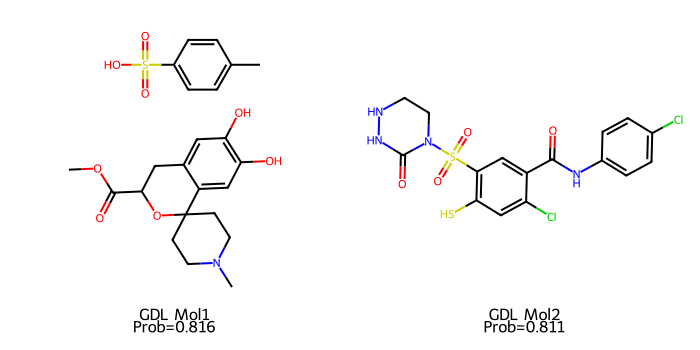

In [ ]:
# ==========================================
# GDL FINAL PIPELINE (MATCHED TO THIS NOTEBOOK)
# ==========================================

import numpy as np
import pandas as pd
import torch
from torch.utils.data import WeightedRandomSampler
from torch_geometric.loader import DataLoader

from rdkit import Chem
from rdkit.Chem import Descriptors, Draw
from rdkit.Chem import Lipinski as RdLipinski, Crippen, QED

# -------------------------------------------------
# 0) Veri kaynağını seç
# -------------------------------------------------
if "df_all" in globals():
    df_source = df_all.copy().reset_index(drop=True)
elif "df" in globals():
    df_source = df.copy().reset_index(drop=True)
else:
    raise ValueError("Ne df_all ne de df bulundu.")

if "results_df" not in globals():
    raise ValueError("results_df bulunamadı. Önce cross-validation hücresini çalıştır.")

if "cross_validate_training" not in globals():
    print("cross_validate_training tanımlı, ama final pipeline ona bağlı değil; devam ediliyor.")

# -------------------------------------------------
# 1) En iyi fold'u seç
# -------------------------------------------------
auc_col = "test_roc_auc" if "test_roc_auc" in results_df.columns else results_df.columns[-1]
best_fold_idx = int(results_df[auc_col].astype(float).idxmax())
best_fold_number = best_fold_idx + 1

print(f"Using AUC column: {auc_col}")
print(f"Using best fold: {best_fold_number}")

# -------------------------------------------------
# 2) Aynı split'i notebook ile aynı mantıkta yeniden kur
# -------------------------------------------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

for fold, (train_idx, temp_idx) in enumerate(
    skf.split(df_source.smiles, df_source.HIV_active), start=1
):
    if fold == best_fold_number:
        set_seed(SEED + fold)

        df_train = df_source.iloc[train_idx].reset_index(drop=True)
        df_temp  = df_source.iloc[temp_idx].reset_index(drop=True)

        df_temp = df_temp.sample(frac=1.0, random_state=SEED + fold).reset_index(drop=True)
        half = len(df_temp) // 2
        df_val = df_temp[:half].reset_index(drop=True)
        df_test = df_temp[half:].reset_index(drop=True)
        break

print(f"Train: {len(df_train)}, Val: {len(df_val)}, Test: {len(df_test)}")

# -------------------------------------------------
# 3) Dataset / Loader
# -------------------------------------------------
train_ds = HIVDatasetVN(df_train, augment=True,  virtual_node=True)
val_ds   = HIVDatasetVN(df_val,   augment=False, virtual_node=True)
test_ds  = HIVDatasetVN(df_test,  augment=False, virtual_node=True)

labels_train = df_train.HIV_active.values
class_counts = np.array([len(np.where(labels_train == t)[0]) for t in np.unique(labels_train)])
weights = 1.0 / class_counts
samples_weight = np.array([weights[int(t)] for t in labels_train])
samples_weight = torch.from_numpy(samples_weight).double()
sampler = WeightedRandomSampler(samples_weight, num_samples=len(samples_weight), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# -------------------------------------------------
# 4) Modeli notebooktaki resmi eğitim fonksiyonu ile yeniden eğit
# -------------------------------------------------
sample_data = train_ds.get(0)
model, history, best_val_auc = train_onecycle(
    train_loader, val_loader, sample_data, desc_dim=6
)

# -------------------------------------------------
# 5) Test prediction üret
# -------------------------------------------------
crit = focal_loss
test_metrics, test_true, test_pred = run_validation(test_loader, model, crit)

smiles_test = df_test["smiles"].reset_index(drop=True)
y_test = np.array(test_true).reshape(-1)
y_prob = np.array(test_pred).reshape(-1)
y_pred = (y_prob >= 0.5).astype(int)

# -------------------------------------------------
# 6) Prediction dataframe
# -------------------------------------------------
df_pred = pd.DataFrame({
    "fold": best_fold_number,
    "smiles": smiles_test,
    "y_true": y_test,
    "y_pred": y_pred,
    "y_prob": y_prob
})

# -------------------------------------------------
# 7) Top 10 aday
# -------------------------------------------------
top_df = df_pred.sort_values(by="y_prob", ascending=False).head(100).reset_index(drop=True)

# -------------------------------------------------
# 8) Descriptor hesaplama
# -------------------------------------------------
def compute_desc(sm):
    mol = Chem.MolFromSmiles(sm)
    if mol is None:
        return None

    mw = Descriptors.MolWt(mol)
    logp = Crippen.MolLogP(mol)
    hbd = RdLipinski.NumHDonors(mol)
    hba = RdLipinski.NumHAcceptors(mol)
    tpsa = Descriptors.TPSA(mol)
    rot = RdLipinski.NumRotatableBonds(mol)
    qed = QED.qed(mol)
    lip = (mw <= 500) and (logp <= 5) and (hbd <= 5) and (hba <= 10)

    return {
        "MW": mw,
        "LogP": logp,
        "HBD": hbd,
        "HBA": hba,
        "TPSA": tpsa,
        "RotatableBonds": rot,
        "QED": qed,
        "Lipinski": lip
    }

rows = []
for _, row in top_df.iterrows():
    d = compute_desc(row["smiles"])
    if d is not None:
        d.update(row.to_dict())
        rows.append(d)

df_desc = pd.DataFrame(rows)

# -------------------------------------------------
# 9) Ortak 13 sütun
# -------------------------------------------------
df_desc = df_desc[[
    "MW", "LogP", "HBD", "HBA", "TPSA", "RotatableBonds",
    "QED", "smiles", "fold", "y_true", "y_pred", "y_prob", "Lipinski"
]]

print("\nGDL TOP 10 CANDIDATES:")
display(df_desc)

# -------------------------------------------------
# 10) Final 2 aday
# -------------------------------------------------
filtered_df = df_desc[df_desc["Lipinski"] == True].copy()

if len(filtered_df) >= 2:
    final_df = filtered_df.sort_values(by=["y_prob", "QED"], ascending=False).head(2).copy()
else:
    print("Warning: No Lipinski-passing molecules found in top 100. Falling back to best available candidates.")
    final_df = df_desc.sort_values(by=["y_prob", "QED"], ascending=False).head(2).copy()
# -------------------------------------------------
# 11) Kaydet
# -------------------------------------------------
df_desc.to_csv("GDL_top_10_candidates.csv", index=False)
final_df.to_csv("GDL_final_2_candidates.csv", index=False)
final_df["smiles"].to_csv("GDL_docking_input.smi", index=False, header=False)

print("\nSaved: GDL_top_10_candidates.csv")
print("Saved: GDL_final_2_candidates.csv")
print("Saved: GDL_docking_input.smi")

# -------------------------------------------------
# 12) Renkli çizim
# -------------------------------------------------
mols = [Chem.MolFromSmiles(sm) for sm in final_df["smiles"]]

img = Draw.MolsToGridImage(
    mols,
    molsPerRow=2,
    subImgSize=(350, 350),
    legends=[
        f"GDL Mol1\nProb={final_df.iloc[0]['y_prob']:.3f}" if len(final_df) > 0 else "",
        f"GDL Mol2\nProb={final_df.iloc[1]['y_prob']:.3f}" if len(final_df) > 1 else ""
    ]
)

display(img)

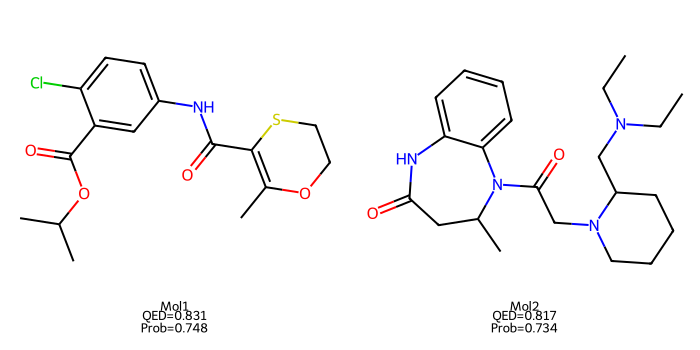

In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw

# QED en yüksek 2 molekül
smiles_list = [
    "CC1=C(C(=O)Nc2ccc(Cl)c(C(=O)OC(C)C)c2)SCCO1",
    "CCN(CC)CC1CCCCN1CC(=O)N1c2ccccc2NC(=O)CC1C"
]

probs = [0.748, 0.734]  # y_prob değerlerin (istersen değiştirebilirsin)
qeds  = [0.831, 0.817]

mols = [Chem.MolFromSmiles(sm) for sm in smiles_list]

img = Draw.MolsToGridImage(
    mols,
    molsPerRow=2,
    subImgSize=(350, 350),
    legends=[
        f"Mol1\nQED={qeds[0]:.3f}\nProb={probs[0]:.3f}",
        f"Mol2\nQED={qeds[1]:.3f}\nProb={probs[1]:.3f}"
    ]
)

display(img)